# Overview:
This notebook will assess the retail trends, patterns and insights of the selected dataset to better understand customer wants, needs and shopping tendencies to, as a result, help marketing and inform planning decisions.


In [19]:
import pandas as pd
import numpy as np

In [20]:
db = pd.read_csv('retail_sales_dataset.csv')
db_copy = db.copy()
db_copy.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [21]:
db_copy.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [22]:
db_copy.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [23]:
#Converting Date to DateTime Format for easier usage:
db_copy['Date'] = pd.to_datetime(db_copy['Date'])

#Converting string columns into teh correct dataset
db_copy[['Gender', 'Transaction ID', 'Product Category']] = db_copy[['Gender', 'Transaction ID', 'Product Category']].astype('string')

#Converting category data columns into the appropriate dataset:
db_copy['Gender'] = db_copy['Gender'].astype('category')
db_copy['Product Category'] = db_copy['Product Category'].astype('category')

print(db_copy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   string        
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   category      
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   category      
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(4), object(1), string(1)
memory usage: 57.0+ KB
None


In [24]:
db_copy.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Dataset was actaully uploaded generally clean and contains no NA or NULL values, hence no correction adjustments needed here. Moved on to Data Validation and Analysis Preperations:

In [25]:
print(db_copy.shape)


(1000, 9)


In [26]:
#I also decided to rename the Total Amount column just so that it didn't become confusing when I started adding new int columns later that do calculations!
db_copy.rename(columns={"Total Amount": "Total Sale Price"}, inplace=True)
print(db_copy.columns.tolist())


['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Sale Price']


## Dataset Structural Validation Check Breakdown:
Can confirm that the dataset still has 1000 elements and 9 columns as it did when imported, meaning no elements or data has gone missing.

All columns are as expected and have been renamed accordingly if felt needed.

No missing element values were detected or observed. 

Quick top and tail visual checks confirm that all values seem to look reasonable and ready for usage.

In [27]:
# Check each row to see if it has any duplicates in the dataset:
duplicate_rows = db_copy.duplicated().sum()
print("N0. of duplicate rows:", duplicate_rows)

# Check each transaction ID is unique:
duplicate_ID = db_copy.duplicated("Transaction ID").sum()
print("N0. of duplicate ID's:", duplicate_ID)

# Quick check to make sure all unique elements = nuumber of total elements
print(db_copy["Transaction ID"].nunique())
print(len(db_copy))

N0. of duplicate rows: 0
N0. of duplicate ID's: 0
1000
1000


## Data Duplicates and Integrity Checks:


x No fully duplicated rows and hence no actions needed

x All transaction ID's are unique and hence all transactions individual 

x Number check confirms that all elements of the dataframe and unique and equal to number of rows.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

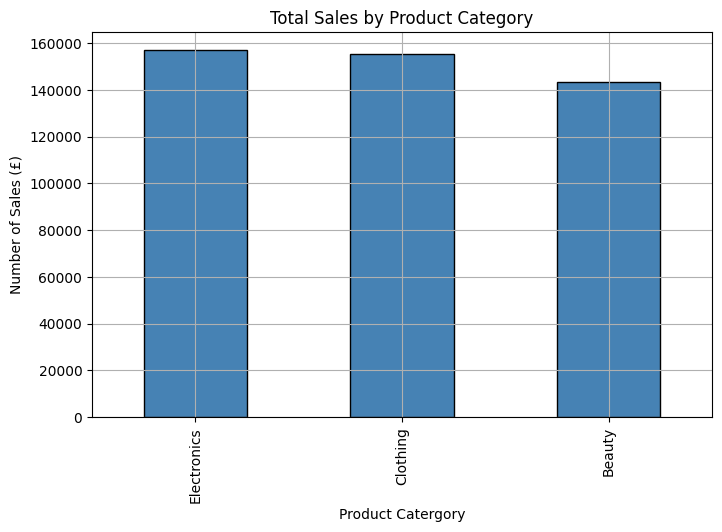

In [29]:
category_sales = db_copy.groupby('Product Category')['Total Sale Price'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar',color='steelblue', edgecolor='black')

#Finalize Visualization:
plt.title('Total Sales by Product Category')
plt.xlabel('Product Catergory')
plt.ylabel('Number of Sales (£)')
plt.grid()



## Inital Graphing Insights:

On intal observation electronics dominate the market with their overall revenue tally. This suggest there is a stronger customer supply and demand for these compared to beauty and clothing. 

Now this had been observed I will now investigate these trends based on time analysis. 

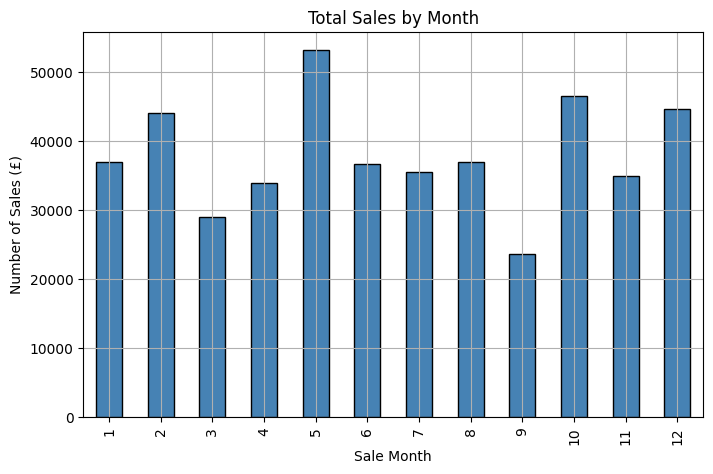

In [30]:
# new column that shows each transaction month
db_copy['Month'] = db_copy['Date'].dt.month


month_sales = db_copy.groupby('Month')['Total Sale Price'].sum().sort_index()
plt.figure(figsize=(8,5))
month_sales.plot(kind='bar',color='steelblue', edgecolor='black')

#Finalize Visualization:
plt.title('Total Sales by Month')
plt.xlabel('Sale Month')
plt.ylabel('Number of Sales (£)')
plt.grid()


 Identified that the most profitable month for revenue is May, followed by October. This trend could be explained by a number of reasonings. Next I will assess the relationship between categories and revenue in the month of may.

In [31]:
db_May = db_copy[db_copy['Month'] == 5]
print(db_May)


#Verify:
print(db_May['Month'].unique()) 


    Transaction ID       Date Customer ID  Gender  Age Product Category  \
3                4 2023-05-21     CUST004    Male   37         Clothing   
4                5 2023-05-06     CUST005    Male   30           Beauty   
30              31 2023-05-23     CUST031    Male   44      Electronics   
36              37 2023-05-23     CUST037  Female   18           Beauty   
47              48 2023-05-16     CUST048    Male   54      Electronics   
..             ...        ...         ...     ...  ...              ...   
973            974 2023-05-03     CUST974    Male   47           Beauty   
984            985 2023-05-30     CUST985  Female   19      Electronics   
987            988 2023-05-28     CUST988  Female   63         Clothing   
989            990 2023-05-25     CUST990  Female   58           Beauty   
995            996 2023-05-16     CUST996    Male   62         Clothing   

     Quantity  Price per Unit  Total Sale Price  Month  
3           1             500             

In [32]:
print(db_May.groupby('Product Category')['Total Sale Price'].sum().sort_values(ascending =False))
month_sales = db_copy.groupby('Month')['Total Sale Price'].sum().sort_values(ascending=False)

print(db_May.groupby('Product Category')['Quantity'].sum().sort_values(ascending =False))
print(db_May['Age'].mean())
print(db_May['Age'].median())


Product Category
Electronics    23245
Clothing       17455
Beauty         12450
Name: Total Sale Price, dtype: int64
Product Category
Clothing       97
Electronics    97
Beauty         65
Name: Quantity, dtype: int64
42.42857142857143
44.0


Peak Category for revenue is Electronics

Peak Category for Quantity Purchased is Clothing and Electronics

Most common age of purchasing around 42-44



Spend by age band:
    
Spend by gender:
    
Average order value by category

In [41]:
# Define edges and labels for age group cut 
bins=[0,17,30,40,55,70,100]
labels= ['Minor','Young Adult', 'Adult','Middle Aged', 'Late Middle Aged', 'Senior']

db_copy['Age_band'] = pd.cut(db_copy['Age'], bins=bins, labels=labels, right=False)
print(db_copy.groupby('Age_band')['Quantity'].sum().sort_values(ascending =False))
# Age Group purchasing the most = 40-55 YO

~

Age_band
Middle Aged         865
Young Adult         625
Late Middle Aged    515
Adult               509
Minor                 0
Senior                0
Name: Quantity, dtype: int64
